<a href="https://colab.research.google.com/github/jetisaplane1/AI-for-Business-BUS4-118S/blob/dev/ML_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1**

In [9]:
from google.colab import files
uploaded = files.upload()



Saving house_part1_data.csv to house_part1_data (4).csv


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# Data Source (Rubric Requirement)
# -----------------------------
# Data Source: house_part1_data.csv (uploaded into Colab).
# Note: This dataset was generated for this assignment using realistic pricing assumptions
# (price increases with square footage and differs by location: Downtown/Suburb/Rural).

# -----------------------------
# Load Data from CSV (Module 2 skill)
# -----------------------------
df = pd.read_csv("house_part1_data.csv")

# Features and target
X = df[['square_footage', 'location']]
y = df['price']

# Preprocessing: One-hot encode location
preprocessor = ColumnTransformer(
    transformers=[
        ('location', OneHotEncoder(sparse_output=False), ['location'])
    ],
    remainder='passthrough'
)

# Pipeline: preprocessing + regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict price for a 2000 sq ft house in Downtown
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Downtown']})
predicted_price = model.predict(new_house)[0]

print(f"Predicted price for a 2000 sq ft house in Downtown: ${predicted_price:,.2f}")

# Display model coefficients
feature_names = (
    model.named_steps['preprocessor']
    .named_transformers_['location']
    .get_feature_names_out(['location'])
).tolist() + ['square_footage']

coefficients = model.named_steps['regressor'].coef_

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

# -----------------------------
# Explanation (Rubric Requirement)
# -----------------------------
print("\nExplanation:")

print(f"1) Square Footage Effect:")
print(f"   The coefficient for square footage is {coefficients[-1]:,.2f}.")
print("   This means that for every additional 1 square foot, the house price increases by about")
print("   $217.59, holding location constant.")

print("\n2) Location Effects:")
print("   The location coefficients represent how much the price changes relative to the baseline location.")
print("   Downtown adds about $44,858 to the price, Rural reduces price by about $34,829,")
print("   and Suburb reduces price by about $10,029 compared to the baseline.")


Predicted price for a 2000 sq ft house in Downtown: $493,222.27

Model Coefficients:
location_Downtown: 44858.07
location_Rural: -34828.76
location_Suburb: -10029.31
square_footage: 217.59

Explanation:
1) Square Footage Effect:
   The coefficient for square footage is 217.59.
   This means that for every additional 1 square foot, the house price increases by about
   $217.59, holding location constant.

2) Location Effects:
   The location coefficients represent how much the price changes relative to the baseline location.
   Downtown adds about $44,858 to the price, Rural reduces price by about $34,829,
   and Suburb reduces price by about $10,029 compared to the baseline.


# Part 2

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# Data Source (Rubric Requirement)
# -----------------------------
# Data Source: customer_churn_part2.csv (uploaded into Google Colab).
# This dataset contains 100+ records with customer demographics, usage, spending,
# service calls, region, and churn label.

# -----------------------------
# Load Data from CSV (Module 2 skill)
# -----------------------------
df = pd.read_csv("customer_churn_part2.csv")

# -----------------------------
# Features and target
# -----------------------------
X = df[['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls', 'region']]
y = df['churn']

# -----------------------------
# Preprocessing: scale numeric + one-hot encode categorical
# -----------------------------
numeric_features = ['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls']
categorical_features = ['region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ]
)

# -----------------------------
# Pipeline: preprocessing + logistic regression
# -----------------------------
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# -----------------------------
# Split + Train
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Predict churn probability for a new customer
# -----------------------------
new_customer = pd.DataFrame({
    'age': [35],
    'monthly_usage_hours': [20],
    'purchase_amount': [150],
    'customer_service_calls': [5],
    'region': ['West']
})

churn_probability = model.predict_proba(new_customer)[0][1]  # prob of class 1 (churn)

# Classify based on threshold (0.5)
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0

print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn risk, 0 = not at risk): {churn_prediction}")

# -----------------------------
# Display model coefficients (correct feature order)
# -----------------------------
ohe_feature_names = (
    model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
    .tolist()
)

feature_names = numeric_features + ohe_feature_names
coefficients = model.named_steps['classifier'].coef_[0]

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

# -----------------------------
# Interpretation (Rubric Requirement)
# -----------------------------
print("\nExplanation:")
print("The churn probability is the model’s estimate of how likely the customer is to churn (leave).")
print("For example, a probability of 0.70 means the model estimates a 70% chance of churn.")
print("Using a 0.5 threshold means customers above 0.50 are classified as 'at risk' (churn = 1).")
print("Businesses can use this to reduce churn by targeting at-risk customers with retention actions")
print("such as discounts, proactive support outreach, plan adjustments, or improving service quality.")

print("\nCoefficient Interpretation:")
print("Positive coefficients increase churn likelihood.")
print("Negative coefficients decrease churn likelihood.")

print("\nFrom this model:")
print("- More customer service calls strongly increase churn risk.")
print("- Higher monthly usage decreases churn risk.")
print("- Higher purchase amounts decrease churn risk.")
print("- Older customers are slightly less likely to churn.")


Churn Probability for new customer: 0.88
Churn Prediction (1 = churn risk, 0 = not at risk): 1

Model Coefficients:
age: -0.3250
monthly_usage_hours: -0.4094
purchase_amount: -0.3669
customer_service_calls: 0.9277
region_East: -0.2385
region_North: 0.0329
region_South: 0.2420
region_West: -0.0064

Explanation:
The churn probability is the model’s estimate of how likely the customer is to churn (leave).
For example, a probability of 0.70 means the model estimates a 70% chance of churn.
Using a 0.5 threshold means customers above 0.50 are classified as 'at risk' (churn = 1).
Businesses can use this to reduce churn by targeting at-risk customers with retention actions
such as discounts, proactive support outreach, plan adjustments, or improving service quality.

Coefficient Interpretation:
Positive coefficients increase churn likelihood.
Negative coefficients decrease churn likelihood.

From this model:
- More customer service calls strongly increase churn risk.
- Higher monthly usage dec

## Part 3

Saving customer_segmentation_part3.csv to customer_segmentation_part3 (1).csv


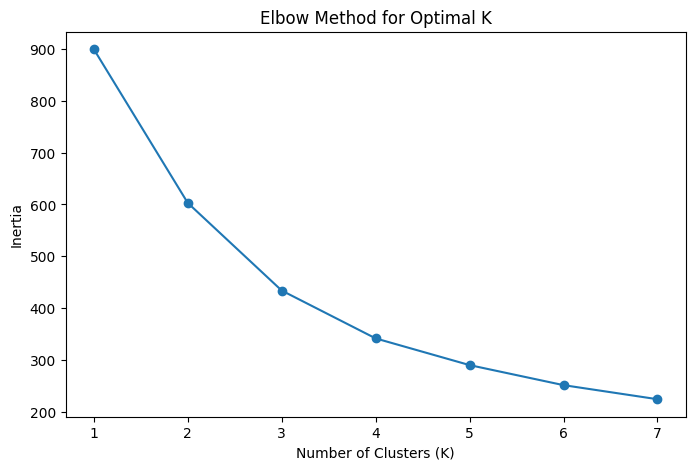


K Selection Justification:
Based on the elbow plot, the inertia decreases sharply from K=1 to K=3,
but the improvement slows after K=3. Therefore, K=3 is a good balance between
model simplicity and capturing meaningful customer segments.

Cluster Characteristics (Averages):
         annual_spending  purchase_frequency    age
cluster                                            
0                1676.83                7.79  44.78
1                 985.97               11.41  29.96
2                 535.11                4.93  38.29

Targeted Marketing Strategies:

Cluster 0 Strategy:
- High-spending customers: Offer VIP perks, exclusive promotions, early access, and loyalty rewards.

Cluster 1 Strategy:
- Frequent buyers: Offer subscription plans, bundle deals, and personalized product recommendations.

Cluster 2 Strategy:
- Lower engagement customers: Send re-engagement campaigns, first-time buyer discounts, and reminders.

Saved clustered customers to: customer_segments.csv
Saved elbow

In [1]:
# ==============================
# PART 3: Customer Segmentation (K-Means)
# ==============================

import pandas as pd
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# Upload CSV
# -----------------------------
uploaded = files.upload()

# -----------------------------
# Data Source (Rubric Requirement)
# -----------------------------
# Data Source: customer_segmentation_part3.csv (uploaded into Google Colab).
# Dataset contains 100+ customers with annual spending, purchase frequency, age, and region.

df = pd.read_csv("customer_segmentation_part3.csv")

# -----------------------------
# Preprocess data: select numerical features and scale them
# -----------------------------
features = ['annual_spending', 'purchase_frequency', 'age']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Elbow Method: find a good K
# -----------------------------
inertia = []
K_values = range(1, 8)  # a bit wider than starter code (stronger justification)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(K_values), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()

# -----------------------------
# Choose K (Justification)
# -----------------------------
optimal_k = 3  # chosen because inertia drops sharply up to 3, then flattens (typical elbow)

print("\nK Selection Justification:")
print("Based on the elbow plot, the inertia decreases sharply from K=1 to K=3,")
print("but the improvement slows after K=3. Therefore, K=3 is a good balance between")
print("model simplicity and capturing meaningful customer segments.")

# -----------------------------
# Apply K-Means clustering
# -----------------------------
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------
# Analyze clusters: average characteristics
# -----------------------------
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("\nCluster Characteristics (Averages):")
print(cluster_summary)

# -----------------------------
# Marketing strategies for each cluster
# -----------------------------
print("\nTargeted Marketing Strategies:")
for cluster_id in range(optimal_k):
    avg_spend = cluster_summary.loc[cluster_id, 'annual_spending']
    avg_freq = cluster_summary.loc[cluster_id, 'purchase_frequency']

    print(f"\nCluster {cluster_id} Strategy:")
    if avg_spend >= 1200:
        print("- High-spending customers: Offer VIP perks, exclusive promotions, early access, and loyalty rewards.")
    elif avg_freq >= 10:
        print("- Frequent buyers: Offer subscription plans, bundle deals, and personalized product recommendations.")
    else:
        print("- Lower engagement customers: Send re-engagement campaigns, first-time buyer discounts, and reminders.")

# -----------------------------
# Save cluster results to CSV
# -----------------------------
df.to_csv('customer_segments.csv', index=False)
print("\nSaved clustered customers to: customer_segments.csv")
print("Saved elbow plot to: elbow_plot.png")


# Extra Credit

In [5]:
from google.colab import files
uploaded = files.upload()


Saving sales_data_.csv to sales_data_ (2).csv


6-Month Forecast:
   month  predicted_sales
0     37           240.87
1     38           243.97
2     39           247.07
3     40           250.17
4     41           253.27
5     42           256.37


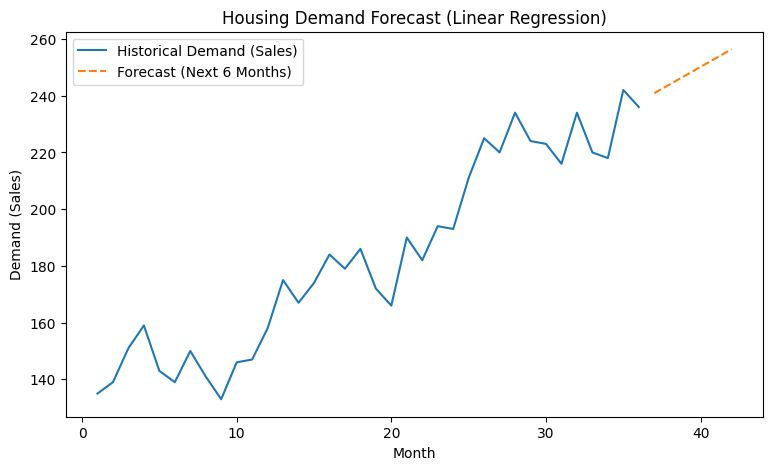


Saved forecast chart to: demand_forecast.png

Assumptions / Challenges / Improvements:
- Assumption: Month number is a valid timeline and demand changes approximately linearly over time.
- Challenge: Linear regression cannot capture strong seasonality or sudden market shocks well.
- Improvements: Add seasonal features (month-of-year), include interest rates, inventory levels,
  and economic indicators; try polynomial regression or time-series models for better accuracy.


In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# -----------------------------
# Load + Clean Data
# -----------------------------
# Data Source: sales_data_.csv (uploaded into Colab).
# Assumes columns: 'month' (integer timeline) and 'sales' (demand proxy).

df = pd.read_csv("sales_data_.csv")

# Basic cleaning (handles missing/invalid rows safely)
df = df.dropna(subset=["month", "sales"])
df = df.sort_values("month")
df["month"] = df["month"].astype(int)

X = df[["month"]]
y = df["sales"]

# -----------------------------
# Train Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

# -----------------------------
# Forecast Next 6 Months
# -----------------------------
last_month = int(df["month"].max())
future_months = pd.DataFrame({"month": range(last_month + 1, last_month + 7)})
predictions = model.predict(future_months)

forecast_df = future_months.copy()
forecast_df["predicted_sales"] = predictions.round(2)

print("6-Month Forecast:")
print(forecast_df)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(9,5))
plt.plot(df["month"], y, label="Historical Demand (Sales)")
plt.plot(future_months["month"], predictions, label="Forecast (Next 6 Months)", linestyle="--")
plt.xlabel("Month")
plt.ylabel("Demand (Sales)")
plt.title("Housing Demand Forecast (Linear Regression)")
plt.legend()
plt.savefig("demand_forecast.png")
plt.show()

print("\nSaved forecast chart to: demand_forecast.png")

# -----------------------------
# Assumptions + Improvements
# -----------------------------
print("\nAssumptions / Challenges / Improvements:")
print("- Assumption: Month number is a valid timeline and demand changes approximately linearly over time.")
print("- Challenge: Linear regression cannot capture strong seasonality or sudden market shocks well.")
print("- Improvements: Add seasonal features (month-of-year), include interest rates, inventory levels,")
print("  and economic indicators; try polynomial regression or time-series models for better accuracy.")
